In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Sampling setup
fs = 200
t = np.arange(0, 1.0, 1 / fs)

# Signals
a = np.sin(2 * np.pi * 10 * t)         
b = np.sin(np.sin(2 * np.pi * 10 * t))  
c = np.sin(2 * np.pi * 20 * t)     

In [ ]:
# Manual convolution function
def manual_convolution_full(x, h):
    nx = len(x)
    nh = len(h)
    y = np.zeros(nx + nh - 1)
    for i in range(nx):
        for j in range(nh):
            y[i + j] += x[i] * h[j]
    return y

# Manual correlation function (using convolution with reversed signal)
def manual_correlate_full(a, b):
    # Reverse the second signal
    b_reversed = np.zeros(len(b))
    for i in range(len(b)):
        b_reversed[i] = b[len(b) - 1 - i]
    # Correlation = convolution with reversed signal
    return manual_convolution_full(a, b_reversed)

# Correlations (full mode)
auto_a = manual_correlate_full(a, a)
cross_ab = manual_correlate_full(a, b)
cross_ac = manual_correlate_full(a, c)

# Lag axis
lags = np.arange(-len(a) + 1, len(a))

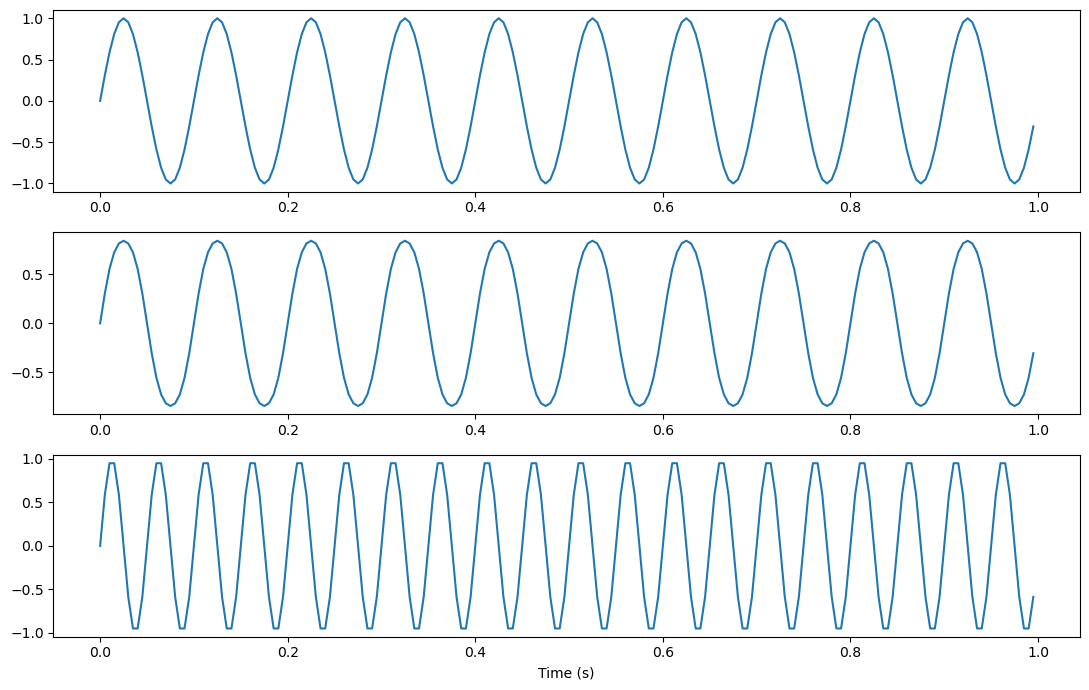

In [ ]:
# Plot signals
plt.figure(figsize=(15, 5))
plt.subplot(3, 1, 1)
plt.plot(t, a)

plt.subplot(3, 1, 2)
plt.plot(t, b)

plt.subplot(3, 1, 3)
plt.plot(t, c)
plt.xlabel('Time (s)')

plt.tight_layout()
plt.show()

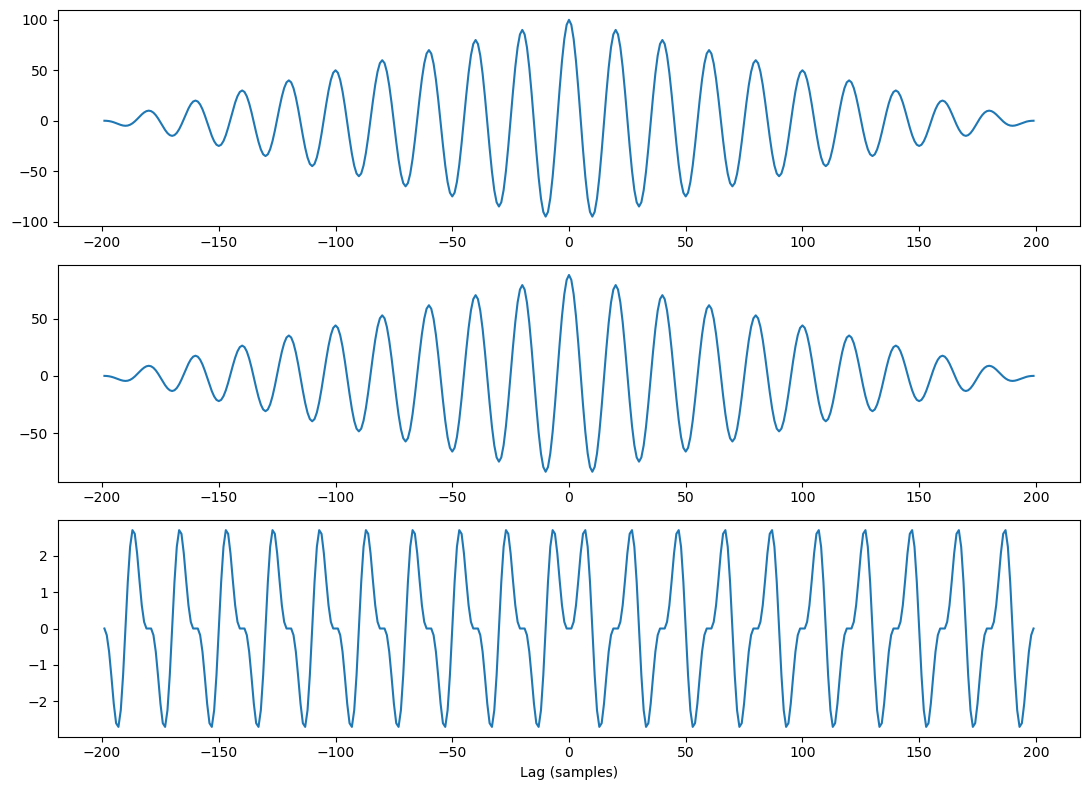

In [ ]:
# Plot correlations
plt.figure(figsize=(15, 5))
plt.subplot(3, 1, 1)
plt.plot(lags, auto_a)

plt.subplot(3, 1, 2)
plt.plot(lags, cross_ab)

plt.subplot(3, 1, 3)
plt.plot(lags, cross_ac)
plt.xlabel('Lag (samples)')

plt.tight_layout()
plt.show()